# IndieGuard: Review 1
Predicting negative-review risk and winning feature combinations for indie games on Steam.

The analysis and the models run live in this notebook, on the committed data (`data/processed/`). Runtime about 6 minutes.

## 1. Problem
Steam refunds a game within 14 days if the player has under 2 hours of playtime, so an early negative review can cost the sale as well as the rating.
We want to tell a studio what to fix before the refund window closes, what to build, and when to patch.
Two tasks: **review level** (will this review be negative?) and **game level** (which success tier will the game land in?).

In [1]:
import json, subprocess, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
sys.path.insert(0, str(ROOT))
PROC, FEAT, RES, DOCS = ROOT / "data/processed", ROOT / "data/processed/features", ROOT / "reports/results", ROOT / "docs"
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:,.3f}".format
SEED = 42

## 2. Data

In [2]:
games = pd.read_parquet(PROC / "games_clean.parquet")
reviews = pd.read_parquet(PROC / "reviews_clean", columns=["appid", "voted_up", "language", "created"])
events = pd.read_parquet(PROC / "events.parquet")
print(f"{len(games):,} games | {len(reviews):,} reviews | {len(events):,} patch and sale announcements")
print(f"negative reviews {(~reviews.voted_up).mean():.1%} | English {reviews.language.eq('english').mean():.1%} | {reviews.language.nunique()} languages")

1,861 games | 1,648,387 reviews | 29,918 patch and sale announcements
negative reviews 10.4% | English 39.5% | 31 languages


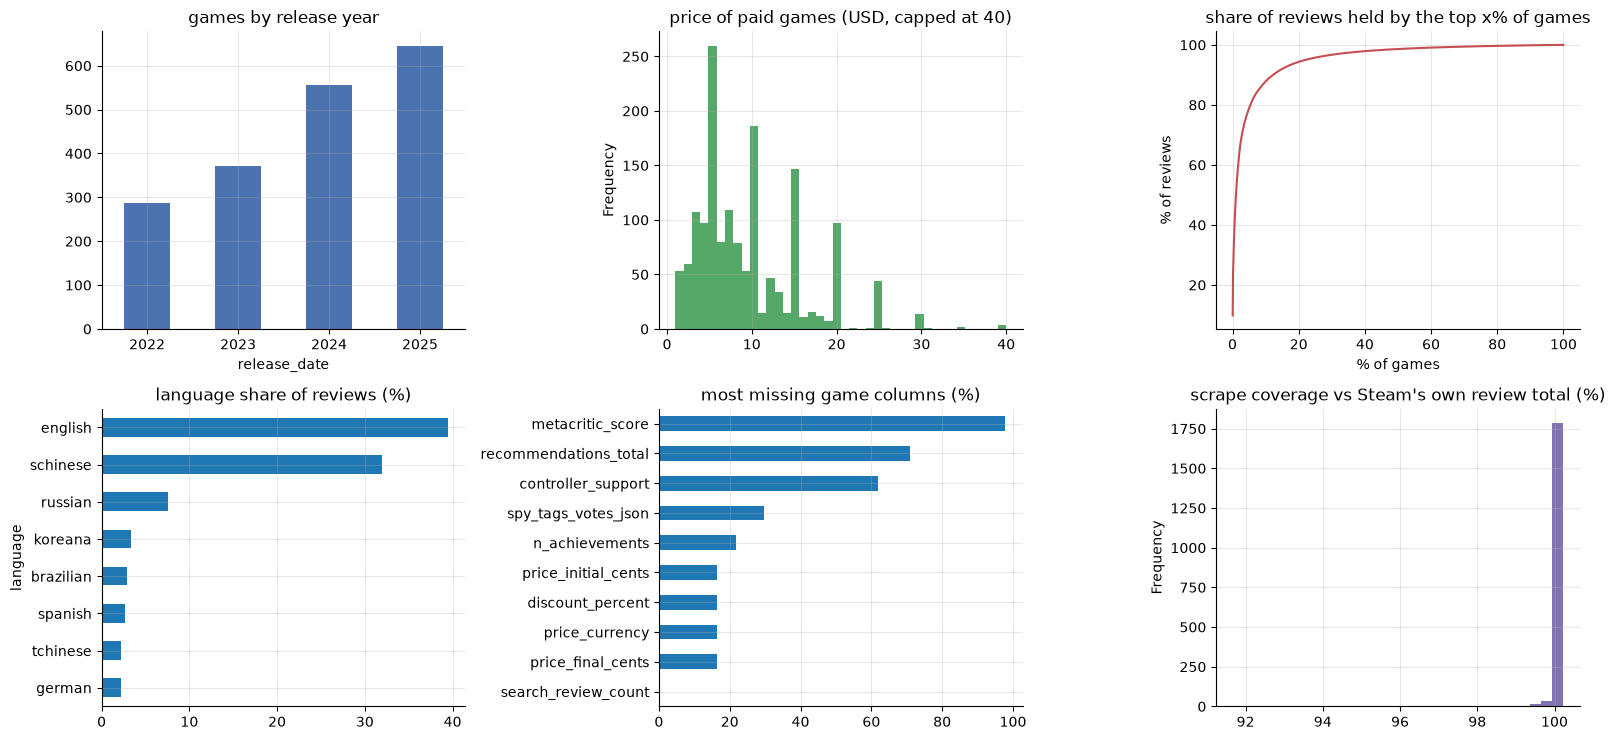

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(16, 7.5))
games.release_date.dt.year.value_counts().sort_index().plot.bar(ax=ax[0, 0], color="#4C72B0", title="games by release year", rot=0)
paid = games.price_usd[games.price_usd > 0]
paid.clip(upper=40).plot.hist(bins=40, ax=ax[0, 1], color="#55A868", title="price of paid games (USD, capped at 40)")
size = np.sort(reviews.groupby("appid").size().values)[::-1]
ax[0, 2].plot(np.arange(1, len(size) + 1) / len(size) * 100, size.cumsum() / size.sum() * 100, color="#C44E52")
ax[0, 2].set(title="share of reviews held by the top x% of games", xlabel="% of games", ylabel="% of reviews")
reviews.language.value_counts(normalize=True).head(8).mul(100).sort_values().plot.barh(ax=ax[1, 0], title="language share of reviews (%)")
games.isna().mean().sort_values(ascending=False).head(10).mul(100).sort_values().plot.barh(ax=ax[1, 1], title="most missing game columns (%)")
ok = games[~games.reviews_capped & (games.steam_total_reviews > 0)]
(ok.reviews_scraped / ok.steam_total_reviews).clip(upper=1.05).mul(100).plot.hist(bins=30, ax=ax[1, 2], color="#8172B3", title="scrape coverage vs Steam's own review total (%)")
plt.tight_layout()

Three facts shape everything later: reviews are concentrated in a few games, 60% are not in English, and the scrape covers almost every review Steam reports.

## 3. Cleaning

dropped 4,612 of 1,652,999 reviews (0.28%); everything else is flagged and kept


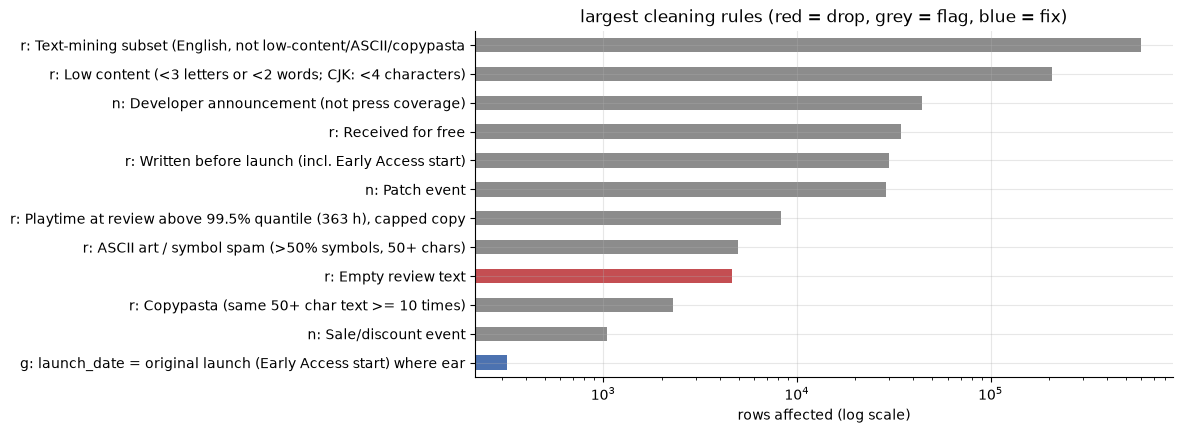

In [4]:
log = pd.DataFrame(json.load(open(PROC / "cleaning_log.json")))
lg = log[log.affected > 0].assign(label=lambda x: x.table.str[0] + ": " + x.rule.str[:60]).sort_values("affected").tail(12)
lg.plot.barh(x="label", y="affected", logx=True, legend=False, figsize=(9, 4.5), xlabel="rows affected (log scale)", ylabel="",
             color=lg.action.map({"drop": "#C44E52", "flag": "#8C8C8C", "fix": "#4C72B0"}), title="largest cleaning rules (red = drop, grey = flag, blue = fix)")
dropped = int(log[log.action == "drop"].affected.sum())
print(f"dropped {dropped:,} of {len(reviews) + dropped:,} reviews ({dropped / (len(reviews) + dropped):.2%}); everything else is flagged and kept")

Only unusable rows are dropped. Suspicious ones (short, spam, copy-paste, pre-launch, free keys, playtime outliers) are flagged, so each analysis picks what it needs, for example `text_mining_ok` for text. Full log: `docs/cleaning_log.md`.

## 4. EDA

14.5% of 1,490 games have 30%+ negative reviews


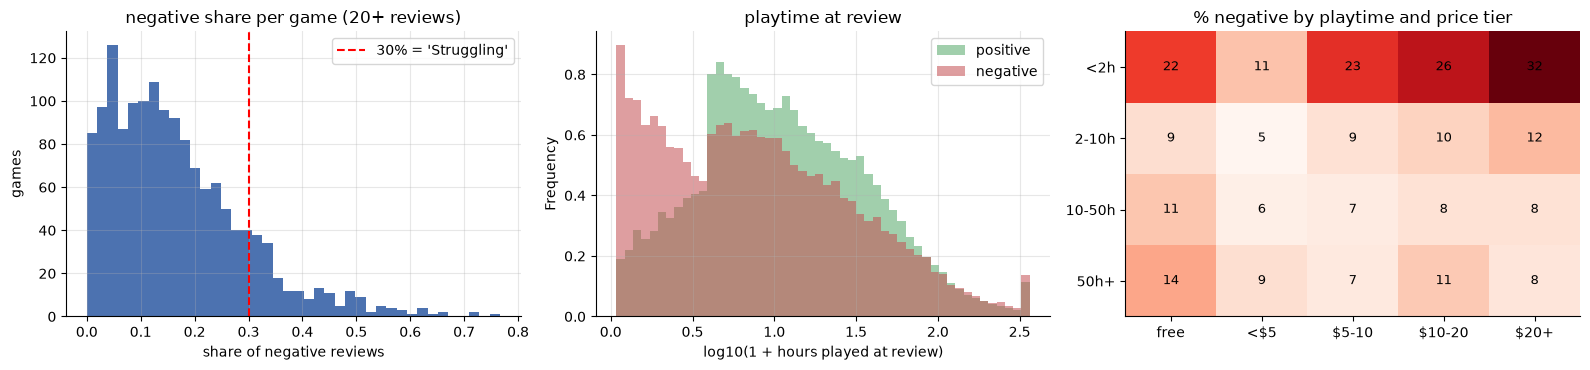

In [5]:
rf = pd.read_parquet(FEAT / "review_features")
g = games[games.steam_total_reviews >= 20].copy()
g["neg_ratio"] = g.steam_total_negative / g.steam_total_reviews

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
g.neg_ratio.hist(bins=40, color="#4C72B0", ax=ax[0])
ax[0].axvline(.30, c="r", ls="--", label="30% = 'Struggling'")
ax[0].set(xlabel="share of negative reviews", ylabel="games", title="negative share per game (20+ reviews)"); ax[0].legend()
smp = rf.sample(300_000, random_state=0)
for lab, c, d in [("positive", "#55A868", smp[smp.target_is_negative == 0]), ("negative", "#C44E52", smp[smp.target_is_negative == 1])]:
    np.log10(1 + d.playtime_at_review_min_capped.clip(lower=0) / 60).plot.hist(bins=50, density=True, alpha=.55, color=c, label=lab, ax=ax[1])
ax[1].set(xlabel="log10(1 + hours played at review)", title="playtime at review"); ax[1].legend()
pt = rf[rf.playtime_bucket >= 0].pivot_table(index="playtime_bucket", columns="price_tier", values="target_is_negative", aggfunc="mean") * 100
im = ax[2].imshow(pt.values, cmap="Reds", aspect="auto")
ax[2].set_xticks(range(5), ["free", "<$5", "$5-10", "$10-20", "$20+"]); ax[2].set_yticks(range(4), ["<2h", "2-10h", "10-50h", "50h+"])
for i in range(pt.shape[0]):
    for j in range(pt.shape[1]):
        ax[2].text(j, i, f"{pt.values[i, j]:.0f}", ha="center", va="center", fontsize=9)
ax[2].set(title="% negative by playtime and price tier"); ax[2].grid(False)
plt.tight_layout()
print(f"{(g.neg_ratio >= .30).mean():.1%} of {len(g):,} games have 30%+ negative reviews")

Under 2 hours of play, 21% of reviews are negative against about 9% for everyone else, and the gap grows with price.

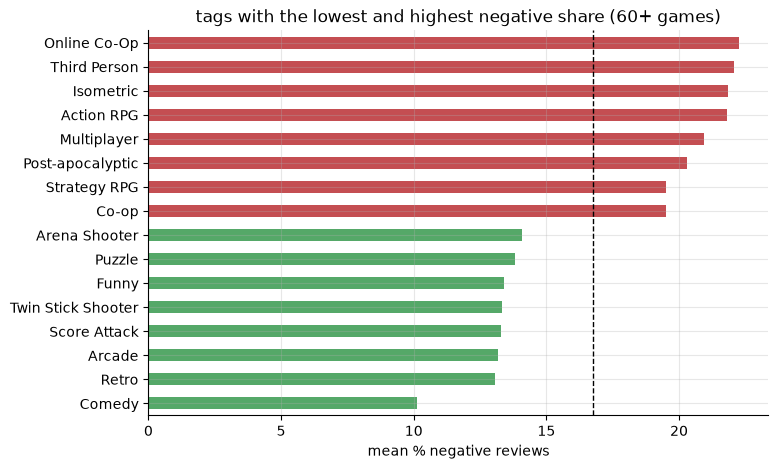

In [6]:
tg = g.assign(tag=g.tags.fillna("").str.split(";")).explode("tag")
tg = tg[~tg.tag.isin(["", "Indie", "Roguelike", "Roguelite", "Singleplayer", "Action", "Adventure"])]
st = tg.groupby("tag").agg(n=("appid", "size"), neg=("neg_ratio", "mean")).query("n >= 60").sort_values("neg")
sel = pd.concat([st.head(8), st.tail(8)])
ax = sel.neg.mul(100).plot.barh(figsize=(8, 5), color=["#55A868"] * 8 + ["#C44E52"] * 8, xlabel="mean % negative reviews", ylabel="",
                                 title="tags with the lowest and highest negative share (60+ games)")
ax.axvline(g.neg_ratio.mean() * 100, c="k", ls="--", lw=1)

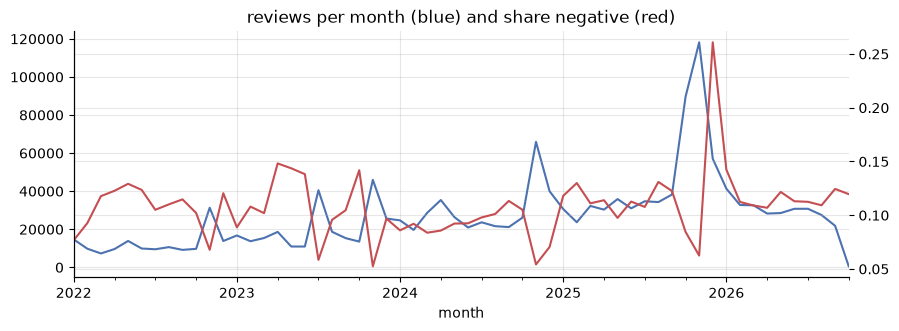

In [7]:
m = reviews.assign(month=reviews.created.dt.tz_localize(None).dt.to_period("M"), neg=~reviews.voted_up).groupby("month").agg(n=("neg", "size"), neg=("neg", "mean"))
m = m[m.index >= "2022-01"]
ax = m.n.plot(color="#4C72B0", figsize=(10, 3.2), title="reviews per month (blue) and share negative (red)")
m.neg.plot(ax=ax.twinx(), color="#C44E52");

Review volume depends on how well games do, so it is an outcome, not something a studio can use to predict reception.
More EDA (29 figures, association tests): `notebooks/02_EDA_Visualizations.ipynb`.

## 5. Features and dimensionality reduction

In [8]:
cat = pd.read_csv(DOCS / "feature_engineering/feature_catalog.csv")
cat.groupby(["table", "group"]).size().rename("entries").reset_index()

,table,group,entries
0,game_features,key,1
1,game_features,launch_time,17
2,game_features,post_launch,3
3,game_outcomes,outcome,1
4,game_targets,key,1
5,game_targets,target,2
6,review_features,at_review,16
7,review_features,key,1
8,review_features,target,1
9,text_svd,at_review,1


k = 68 keeps 75.3% of the training variance
pc_01: Action, Action Roguelike vs Strategy
pc_02: Steam Cloud, Full controller support vs 3D
pc_03: 2D, Pixel Graphics vs 3D
pc_04: RPG, Fantasy vs Casual


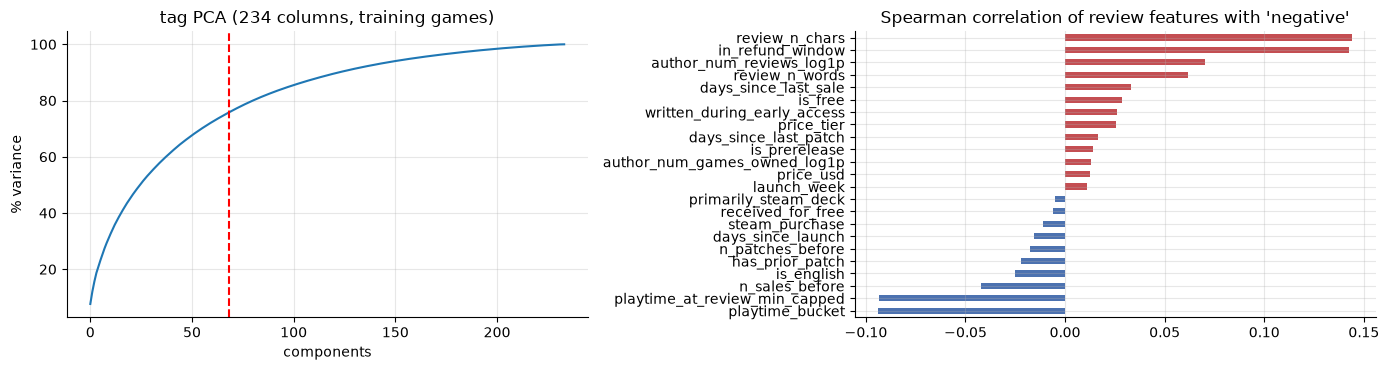

In [9]:
v = pd.read_csv(DOCS / "feature_engineering/tag_pca_variance.csv")
k = 68                                           # elbow of the cumulative variance curve
L = pd.read_csv(DOCS / "feature_engineering/tag_pca_loadings.csv", index_col=0)
L.index = L.index.str.split("__").str[1]

def pcname(pc):
    s = L[pc].sort_values()
    return f"{pc}: {', '.join(s.index[::-1][:2])} vs {s.index[0]}"

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
(v.cumulative * 100).plot(ax=ax[0], xlabel="components", ylabel="% variance", title="tag PCA (234 columns, training games)")
ax[0].axvline(k, c="r", ls="--")
num = smp.select_dtypes("number").drop(columns=["appid", "cv_fold", "recommendationid"], errors="ignore")
cr = num.corr(method="spearman")["target_is_negative"].drop("target_is_negative").sort_values()
cr.plot.barh(ax=ax[1], color=np.where(cr > 0, "#C44E52", "#4C72B0"), title="Spearman correlation of review features with 'negative'")
plt.tight_layout()
print(f"k = {k} keeps {v.cumulative[k - 1]:.1%} of the training variance")
for pc in ["pc_01", "pc_02", "pc_03", "pc_04"]:
    print(pcname(pc))

Tags and store categories (439 columns) are filtered to 234 and reduced to 68 components, fitted on training games only. Review text goes through TF-IDF and SVD. Details: `docs/feature_engineering.md`.

## 6. Targets and split

In [10]:
t = pd.read_parquet(FEAT / "game_targets.parquet")
display(pd.crosstab(t.tier, t.split, margins=True))
rf["part"] = np.where(rf.split == "test", "test", "train fold " + rf.cv_fold.astype(str))
display(rf.groupby("part").agg(reviews=("appid", "size"), games=("appid", "nunique"), negative=("target_is_negative", "mean")))
both = set(rf.appid[rf.split == "train"]) & set(rf.appid[rf.split == "test"])
print("games on both sides of the split:", len(both))

split,test,train,All
tier,,,
Solid,147,605,752
Strong,101,421,522
Struggling,51,165,216
All,299,1191,1490


,reviews,games,negative
part,,,
test,316341,372,0.106
train fold 0,258175,297,0.107
train fold 1,206844,297,0.114
train fold 2,288576,298,0.069
train fold 3,249716,298,0.113
train fold 4,253784,294,0.134


games on both sides of the split: 0


Struggling is 30%+ negative, Strong 10% or less, Solid in between; games under 20 reviews get no tier. The split is by game (80/20, plus 5 folds inside train), so no game is on both sides and every fold has a similar negative rate.

## 7. Models, run live

### 7.1 Game level: success tier

14:26:14  INFO  Loading game features and targets ...


14:26:14  INFO    loaded 1490 eligible games, 92 columns


,macro-F1,balanced acc,Struggling recall
model,,,
Dummy,0.220,0.333,0.000
Logistic Regression,0.430,0.443,0.373
Random Forest,0.361,0.370,0.078
LightGBM,0.388,0.389,0.216


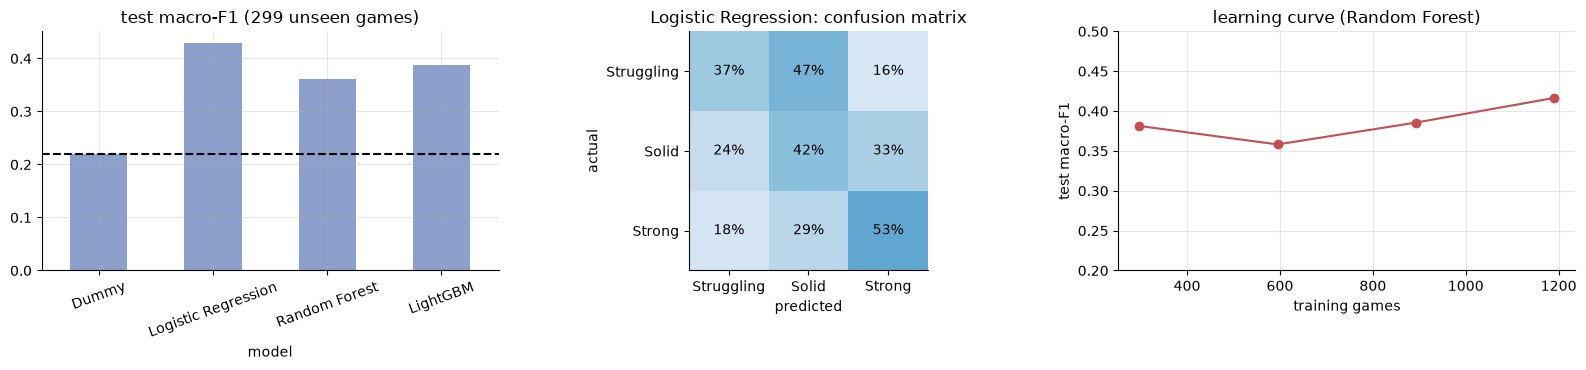

In [11]:
from src.models.game_xgboost import load_game_data, _feature_cols as game_cols
gdf = load_game_data()
gX = game_cols(gdf)
gtr, gte = gdf[gdf.split == "train"], gdf[gdf.split == "test"]

def game_models():
    imp = lambda m: make_pipeline(SimpleImputer(strategy="median"), m)
    return {"Dummy": DummyClassifier(strategy="prior"),
            "Logistic Regression": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(C=0.1, class_weight="balanced", max_iter=3000)),
            "Random Forest": imp(RandomForestClassifier(500, min_samples_leaf=3, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1)),
            "LightGBM": lgb.LGBMClassifier(num_leaves=8, min_child_samples=10, n_estimators=150, learning_rate=.05, class_weight="balanced", random_state=SEED, verbose=-1)}

fitted, rows = {}, []
for name, mdl in game_models().items():
    fitted[name] = mdl.fit(gtr[gX], gtr.tier_code)
    p = mdl.predict(gte[gX])
    rows.append({"model": name, "macro-F1": f1_score(gte.tier_code, p, average="macro"), "balanced acc": balanced_accuracy_score(gte.tier_code, p),
                 "Struggling recall": recall_score(gte.tier_code, p, labels=[0], average="macro")})
gres = pd.DataFrame(rows).set_index("model")
display(gres)

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
gres["macro-F1"].plot.bar(ax=ax[0], color="#8da0cb", rot=20, title=f"test macro-F1 ({len(gte)} unseen games)"); ax[0].axhline(gres.loc["Dummy", "macro-F1"], c="k", ls="--")
best = gres.drop("Dummy")["macro-F1"].idxmax()
cm = confusion_matrix(gte.tier_code, fitted[best].predict(gte[gX]), normalize="true")
ax[1].imshow(cm, cmap="Blues", vmin=0, vmax=1); ax[1].grid(False)
ax[1].set_xticks(range(3), ["Struggling", "Solid", "Strong"]); ax[1].set_yticks(range(3), ["Struggling", "Solid", "Strong"]); ax[1].set(xlabel="predicted", ylabel="actual", title=f"{best}: confusion matrix")
for i in range(3):
    for j in range(3): ax[1].text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center")
fr = []
for f in [.25, .5, .75, 1.0]:
    sub = gtr.sample(frac=f, random_state=SEED)
    mdl = game_models()["Random Forest"].fit(sub[gX], sub.tier_code)
    fr.append(f1_score(gte.tier_code, mdl.predict(gte[gX]), average="macro"))
ax[2].plot([int(len(gtr) * f) for f in [.25, .5, .75, 1.0]], fr, "o-", color="#C44E52"); ax[2].set(xlabel="training games", ylabel="test macro-F1", title="learning curve (Random Forest)", ylim=(.2, .5))
plt.tight_layout()

<Axes: title={'center': 'game level: what the Random Forest relies on'}, xlabel='drop in test macro-F1 when shuffled'>

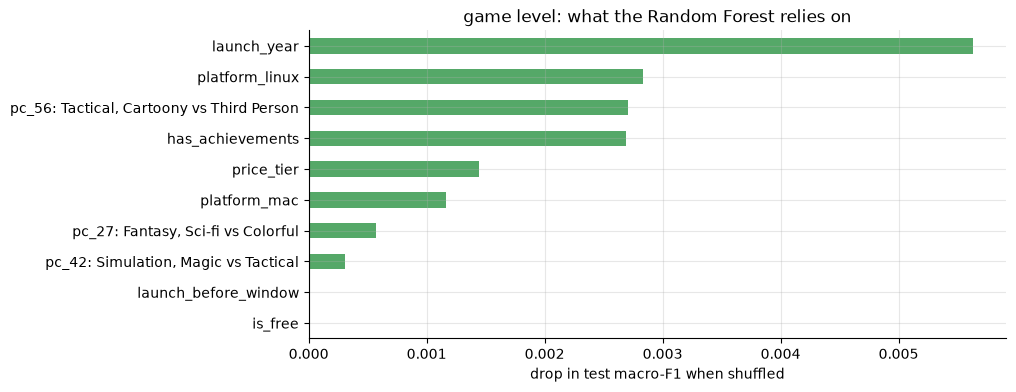

In [12]:
rfm = fitted["Random Forest"]
pi = permutation_importance(rfm, gte[gX], gte.tier_code, scoring="f1_macro", n_repeats=15, random_state=SEED)
pimp = pd.Series(pi.importances_mean, index=gX).sort_values().tail(10)
pimp.rename(lambda c: pcname(c) if c.startswith("pc_") else c).plot.barh(figsize=(9, 4), color="#55A868", xlabel="drop in test macro-F1 when shuffled", title="game level: what the Random Forest relies on")

Untuned, all three beat guessing (0.22), and Logistic Regression is best (0.43), so extra model complexity does not pay with about 1,200 games. The learning curve is noisy and nearly flat: more games would not help, more information would. Struggling games are the hard class.

### 7.2 Review level: will this review be negative? (metadata only)

test (150k reviews from unseen games): PR-AUC 0.255 (guess 0.107) | ROC-AUC 0.721 | top-10% riskiest reviews hold 27% of all negatives (lift 2.7x) | 47 trees


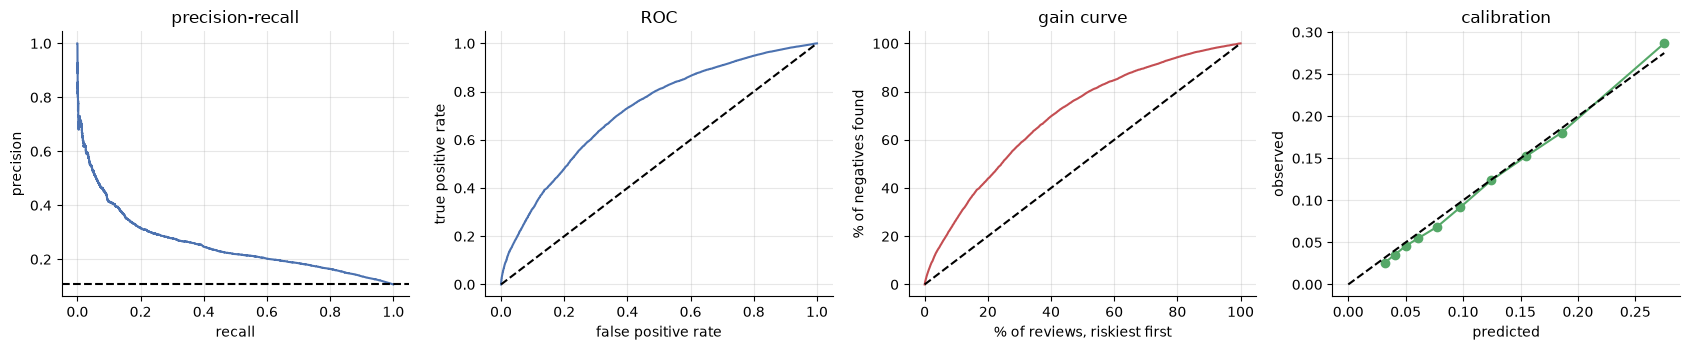

In [13]:
langs = rf.language[rf.split == "train"].value_counts().head(8).index
base = ["playtime_at_review_min_capped", "playtime_bucket", "in_refund_window", "days_since_launch", "is_prerelease", "launch_week", "days_since_last_patch",
        "n_patches_before", "days_since_last_sale", "n_sales_before", "has_prior_patch", "steam_purchase", "received_for_free", "written_during_early_access",
        "primarily_steam_deck", "review_n_chars", "review_n_words", "is_english", "price_usd", "is_free"]    # no author_* columns: they were read at scrape time
X = rf[base].astype("float32").join(pd.get_dummies(rf.language.where(rf.language.isin(langs), "other"), prefix="lang").astype("float32"))
y = rf.target_is_negative.values
tr_i = rf.index[(rf.split == "train") & (rf.cv_fold != 0)].to_series().sample(400_000, random_state=SEED).index
va_i = rf.index[(rf.split == "train") & (rf.cv_fold == 0)].to_series().sample(100_000, random_state=SEED).index
te_i = rf.index[rf.split == "test"].to_series().sample(150_000, random_state=SEED).index

clf = lgb.LGBMClassifier(n_estimators=600, learning_rate=.05, num_leaves=31, min_child_samples=100, random_state=SEED, verbose=-1)
clf.fit(X.loc[tr_i], y[tr_i], eval_set=[(X.loc[va_i], y[va_i])], eval_metric="average_precision", callbacks=[lgb.early_stopping(25, verbose=False)])
pv, pt_ = clf.predict_proba(X.loc[va_i])[:, 1], clf.predict_proba(X.loc[te_i])[:, 1]
p_, r_, th_ = precision_recall_curve(y[va_i], pv)
thr = th_[np.argmax(2 * p_[:-1] * r_[:-1] / np.clip(p_[:-1] + r_[:-1], 1e-9, None))]       # threshold chosen on validation, not test
yt, pred = y[te_i], (pt_ >= thr).astype(int)
order = np.argsort(-pt_); top = yt[order[: len(yt) // 10]].mean() / yt.mean()
print(f"test (150k reviews from unseen games): PR-AUC {average_precision_score(yt, pt_):.3f} (guess {yt.mean():.3f}) | ROC-AUC {roc_auc_score(yt, pt_):.3f} | "
      f"top-10% riskiest reviews hold {yt[order[: len(yt) // 10]].sum() / yt.sum():.0%} of all negatives (lift {top:.1f}x) | {clf.best_iteration_} trees")

fig, ax = plt.subplots(1, 4, figsize=(17, 3.6))
p, r, _ = precision_recall_curve(yt, pt_); ax[0].plot(r, p, color="#4C72B0"); ax[0].axhline(yt.mean(), c="k", ls="--"); ax[0].set(xlabel="recall", ylabel="precision", title="precision-recall")
f, t_, _ = roc_curve(yt, pt_); ax[1].plot(f, t_, color="#4C72B0"); ax[1].plot([0, 1], [0, 1], "k--"); ax[1].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
ax[2].plot(np.arange(1, len(yt) + 1) / len(yt) * 100, yt[order].cumsum() / yt.sum() * 100, color="#C44E52"); ax[2].plot([0, 100], [0, 100], "k--")
ax[2].set(xlabel="% of reviews, riskiest first", ylabel="% of negatives found", title="gain curve")
cal = pd.DataFrame({"p": pt_, "y": yt}).assign(bin=lambda d: pd.qcut(d.p, 10, duplicates="drop")).groupby("bin", observed=True).mean()
ax[3].plot(cal.p, cal.y, "o-", color="#55A868"); ax[3].plot([0, cal.p.max()], [0, cal.p.max()], "k--"); ax[3].set(xlabel="predicted", ylabel="observed", title="calibration")
plt.tight_layout()

<Axes: title={'center': 'review level: what the model relies on'}, xlabel='drop in PR-AUC when shuffled'>

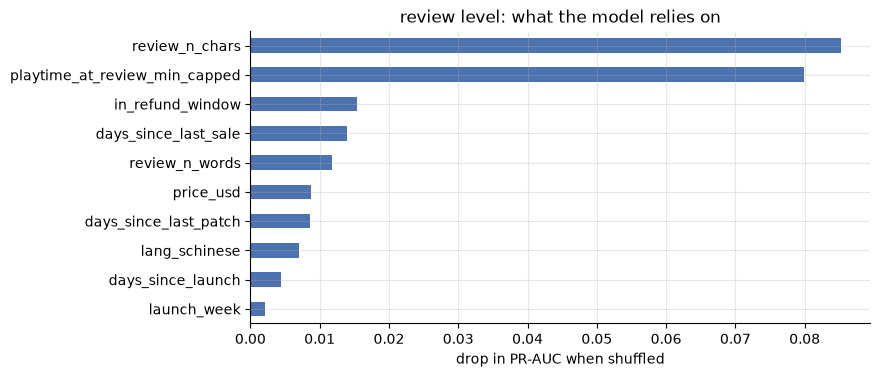

In [14]:
sm = X.loc[te_i].sample(30_000, random_state=SEED)
pi = permutation_importance(clf, sm, y[sm.index], scoring="average_precision", n_repeats=3, random_state=SEED)
pd.Series(pi.importances_mean, index=X.columns).sort_values().tail(10).plot.barh(figsize=(8, 3.8), color="#4C72B0", xlabel="drop in PR-AUC when shuffled", title="review level: what the model relies on")

Metadata alone ranks reviews only modestly: the riskiest 10% hold a quarter to a third of all negatives. Review length, playtime and language lead. What a reviewer wrote is far more informative, as the next step shows.

### 7.3 Review level with the review text (English)

,accuracy,always-positive accuracy,balanced accuracy,precision,recall,F1,ROC-AUC,PR-AUC
"test (60k English reviews, unseen games)",0.942,0.885,0.852,0.756,0.735,0.745,0.963,0.812


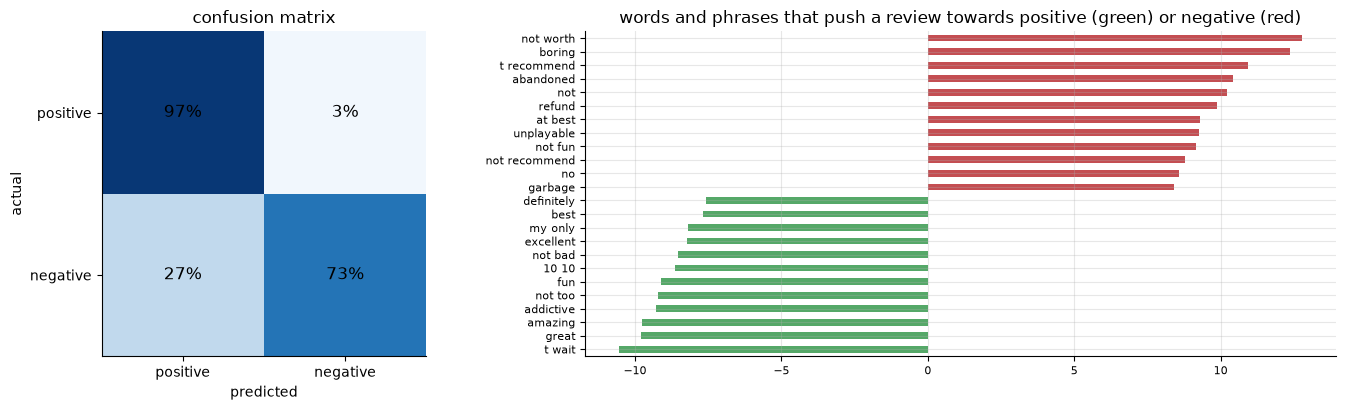

In [15]:
txt = pd.concat([pd.read_parquet(p, columns=["recommendationid", "review", "text_mining_ok"]) for p in sorted((PROC / "reviews_clean").glob("*.parquet"))])
d = txt[txt.text_mining_ok].merge(rf[["recommendationid", "target_is_negative", "in_refund_window", "split", "cv_fold", "language"]], on="recommendationid")
d = d[d.language == "english"]
trn = d[(d.split == "train") & (d.cv_fold != 0)].sample(150_000, random_state=SEED)
val = d[(d.split == "train") & (d.cv_fold == 0)].sample(30_000, random_state=SEED)
tst = d[d.split == "test"].sample(60_000, random_state=SEED)

vec = TfidfVectorizer(max_features=30_000, min_df=20, ngram_range=(1, 2), sublinear_tf=True, token_pattern=r"\w+", dtype=np.float32)
Xtr = vec.fit_transform(trn.review)
lr = LogisticRegression(C=3, class_weight="balanced", max_iter=300).fit(Xtr, trn.target_is_negative)
pv, pt_ = lr.predict_proba(vec.transform(val.review))[:, 1], lr.predict_proba(vec.transform(tst.review))[:, 1]
p_, r_, th_ = precision_recall_curve(val.target_is_negative, pv)
thr = th_[np.argmax(2 * p_[:-1] * r_[:-1] / np.clip(p_[:-1] + r_[:-1], 1e-9, None))]
yt, pred = tst.target_is_negative.values, (pt_ >= thr).astype(int)
text_res = {"accuracy": accuracy_score(yt, pred), "always-positive accuracy": 1 - yt.mean(), "balanced accuracy": balanced_accuracy_score(yt, pred),
            "precision": precision_score(yt, pred), "recall": recall_score(yt, pred), "F1": f1_score(yt, pred), "ROC-AUC": roc_auc_score(yt, pt_), "PR-AUC": average_precision_score(yt, pt_)}
display(pd.Series(text_res, name="test (60k English reviews, unseen games)").to_frame().T)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
cm = confusion_matrix(yt, pred, normalize="true"); ax[0].imshow(cm, cmap="Blues", vmin=0, vmax=1); ax[0].grid(False)
ax[0].set_xticks([0, 1], ["positive", "negative"]); ax[0].set_yticks([0, 1], ["positive", "negative"]); ax[0].set(xlabel="predicted", ylabel="actual", title="confusion matrix")
for i in range(2):
    for j in range(2): ax[0].text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center", fontsize=12)
w = pd.Series(lr.coef_[0], index=vec.get_feature_names_out()).sort_values()
pd.concat([w.head(12), w.tail(12)]).plot.barh(ax=ax[1], color=["#55A868"] * 12 + ["#C44E52"] * 12, title="words and phrases that push a review towards positive (green) or negative (red)", fontsize=8)
plt.tight_layout()

Accuracy clears 90%, but always guessing "positive" already scores about 88%, so judge the model on precision, recall and ROC-AUC. This **detects** a negative review from its own words; it does not forecast one.

## 8. Evaluation

In [16]:
rev, gm, txt_cmp = (pd.read_csv(RES / f).set_index("Model") for f in ["comparison_review.csv", "comparison_game.csv", "comparison_review_text.csv"])
live = pd.DataFrame({
    "this notebook (defaults, samples)": [gres.loc["Logistic Regression", "macro-F1"], gres.loc["Random Forest", "macro-F1"], gres.loc["LightGBM", "macro-F1"],
                                          average_precision_score(y[te_i], clf.predict_proba(X.loc[te_i])[:, 1]), text_res["PR-AUC"]],
    "full protocol (tuned, full data)": [gm.loc["Logistic Regression", "Test"], gm.loc["Random Forest", "Test"], gm.loc["LightGBM", "Test"],
                                         rev.loc["LightGBM", "Test"], txt_cmp.loc["Logistic Regression, full text + metadata", "Test"]],
    "guessing": [.22, .22, .22, y.mean(), .115]},
    index=["game macro-F1: Logistic Regression", "game macro-F1: Random Forest", "game macro-F1: LightGBM", "review PR-AUC: LightGBM (metadata)", "review PR-AUC: text model"])
display(live)

,"this notebook (defaults, samples)","full protocol (tuned, full data)",guessing
game macro-F1: Logistic Regression,0.430,0.423,0.220
game macro-F1: Random Forest,0.361,0.404,0.220
game macro-F1: LightGBM,0.388,0.421,0.220
review PR-AUC: LightGBM (metadata),0.255,0.265,0.106
review PR-AUC: text model,0.812,0.785,0.115


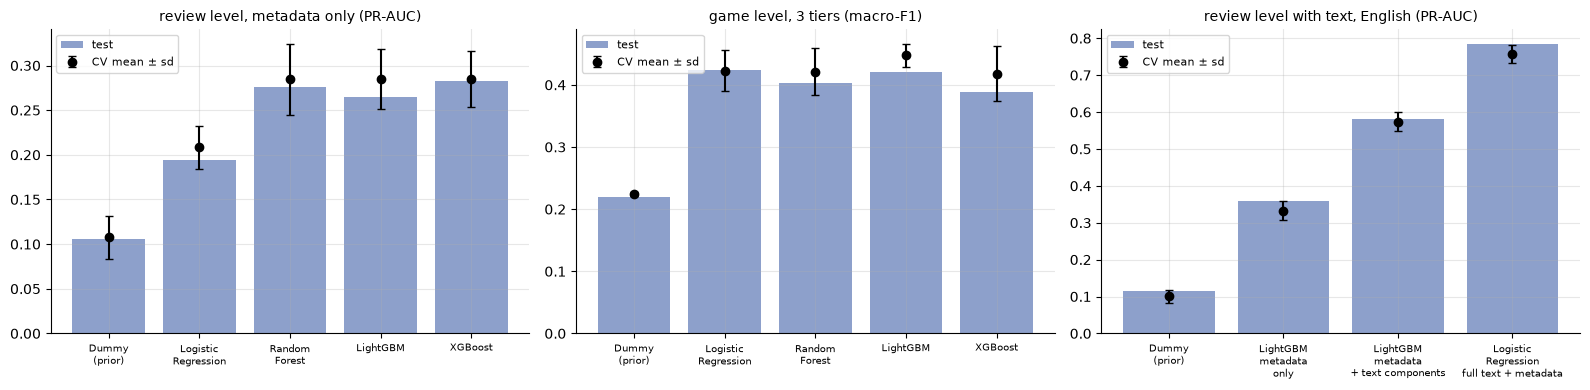

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, dd, title in zip(ax, [rev, gm, txt_cmp], ["review level, metadata only (PR-AUC)", "game level, 3 tiers (macro-F1)", "review level with text, English (PR-AUC)"]):
    a.bar(range(len(dd)), dd.Test, color="#8da0cb", label="test")
    a.errorbar(range(len(dd)), dd["CV mean"], yerr=dd["CV sd"], fmt="ko", capsize=3, label="CV mean ± sd")
    a.set_xticks(range(len(dd)), [n.replace(", ", "\n").replace(" ", "\n", 1) for n in dd.index], fontsize=7)
    a.set_title(title, fontsize=10); a.legend(fontsize=8)
plt.tight_layout()

- The live runs (defaults, samples) land within about 0.04 of the tuned protocol results, so the numbers do not depend on one lucky run.
- Review level: the three tree models tie and Logistic Regression is weaker. Game level: no model wins (299 test games, intervals overlap).
- Text is the big jump: PR-AUC 0.36 to 0.79 on the same reviews. Store metadata says little about how good a game is, so more data would not help, more information would.

## 9. Business findings

refund window: 21.2% negative inside vs 8.8% outside
14.5% of reviews but 29.0% of all negative reviews are inside the window


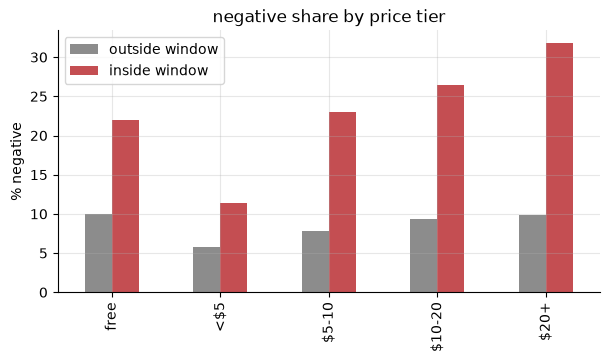

In [18]:
neg = rf.target_is_negative == 1
print(f"refund window: {rf[rf.in_refund_window == 1].target_is_negative.mean():.1%} negative inside vs {rf[rf.in_refund_window == 0].target_is_negative.mean():.1%} outside")
print(f"{rf.in_refund_window.mean():.1%} of reviews but {rf[neg].in_refund_window.mean():.1%} of all negative reviews are inside the window")

by_price = rf.groupby(["price_tier", "in_refund_window"]).target_is_negative.mean().unstack()
by_price.index, by_price.columns = ["free", "<$5", "$5-10", "$10-20", "$20+"], ["outside window", "inside window"]
by_price.mul(100).plot.bar(figsize=(7, 3.4), color=["#8C8C8C", "#C44E52"], ylabel="% negative", title="negative share by price tier");

Early negatives are common and get worse with price: inside the window 11% negative for games under $5, 32% for $20 or more. Outside the window price makes little difference.

In [19]:
low = d.review.str.lower()
from src.analysis.business_findings import THEMES as themes      # same keyword groups as docs/business_findings.md
negs = d[d.target_is_negative == 1]
rows = {k: {"negative when mentioned": d.target_is_negative[low.str.contains(p)].mean(),
            "in early negatives": negs[negs.in_refund_window == 1].review.str.lower().str.contains(p).mean(),
            "in later negatives": negs[negs.in_refund_window == 0].review.str.lower().str.contains(p).mean()} for k, p in themes.items()}
tbl = pd.DataFrame(rows).T
tbl.drop("Praise (control group)").plot.barh(y=["in early negatives", "in later negatives"], figsize=(8, 4), color=["#C44E52", "#8C8C8C"], title="share of negative reviews that mention each theme");
tbl.round(3)

,negative when mentioned,in early negatives,in later negatives
"Bugs, crashes, performance",0.269,0.129,0.153
"Boring, repetitive, grindy",0.378,0.152,0.212
Price and value,0.662,0.045,0.051
"Unfair, frustrating, balance",0.310,0.079,0.175
"Controls, camera, interface",0.281,0.131,0.072
"Too little content, unfinished",0.211,0.063,0.083
"Online, servers, multiplayer",0.134,0.041,0.056
"Monetisation, ads, DLC",0.216,0.014,0.033
Refunds,0.695,0.086,0.029
Praise (control group),0.077,0.252,0.393


Early negatives complain more about controls, camera and interface; later ones about repetition and unfair difficulty. These are keyword groups on English reviews, an initial look until Review 2's topic modelling.

In [20]:
gf = pd.read_parquet(FEAT / "game_features.parquet").merge(t[["appid", "tier"]], on="appid")
tr = gf[(gf.split == "train") & gf.tier.notna()]                        # training games only
res = []
for col, lab in [("n_dlc", "has DLC"), ("has_achievements", "has achievements"), ("launched_in_early_access", "was in Early Access"), ("controller_support_level", "controller support")]:
    r = (tr.tier == "Struggling").groupby(tr[col] > 0).mean()
    res.append({"feature": lab, "without": r.iloc[0] * 100, "with": r.iloc[1] * 100})
pd.DataFrame(res).set_index("feature").plot.barh(figsize=(8, 3.2), color=["#8C8C8C", "#4C72B0"], xlabel="% of games that are Struggling", title="Struggling share, training games only")

<Axes: title={'center': 'Struggling share, training games only'}, xlabel='% of games that are Struggling', ylabel='feature'>

Struggling games are less common with DLC, listed achievements and controller support, and more common after Early Access. These are associations with wide intervals (a DLC count is a snapshot and can reflect success), so they are hypotheses for Review 2's association rules.

**For a studio:** treat the first two hours as the product (opening, controls, stability), patch for depth afterwards, and match price to what the first hour delivers.

## 10. Limits and Review 2
- Associations, not causes. Tags, prices and DLC are snapshots from 1 October 2026; older games had longer to collect negatives.
- Five very large games have only their newest reviews and are left out of the review-level tables. Only 51 test games are Struggling, so cross-validation is reported too.
- Text results cover English reviews (about 40% of the data). Cross-validation is slightly optimistic; test scores are the honest ones.
- Review 2: association rules, topic modelling of complaints, patch and discount impact, and the dashboard.

## 11. Reproduce

In [21]:
import platform, sklearn
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| lightgbm", lgb.__version__)
out = subprocess.run([sys.executable, "-m", "src.features.validate"], cwd=ROOT, capture_output=True, text=True)
print([l for l in (out.stdout + out.stderr).splitlines() if "validate:" in l or l.startswith(("FAIL", "SKIP"))])
# pip install -r requirements.txt; python -m src.features.text; python -m src.features
# python -m src.models.review_models; python -m src.models.game_models; python -m src.models.compare

Python 3.12.10 | pandas 3.0.6 | scikit-learn 1.9.1 | lightgbm 4.7.0


['2026-10-06 14:28:31 INFO validate: 21/21 checks passed']
